### First Stage (دمج بيانات طاهر وعبدالله)

In [83]:
import os
import shutil
import random

# 1. المرجع النهائي (Master List 0-16)
master_categories = [
    'dried_fruit', 'stationery', 'canned_food', 'puffed_food', 'gum', 
    'tissue', 'milk', 'drink', 'dessert', 'seasoner', 
    'personal_hygiene', 'alcohol', 'instant_drink', 'dried_food', 
    'instant_noodles', 'chocolate', 'candy'
]
master_map = {name: i for i, name in enumerate(master_categories)}

# 2. المسارات (تعديل الأسماء لتطابق الـ Tree بالضبط)
base_path = "../data/SAUDI_DATA_DATASET"

# انتبه: أضفت لاسم مجلدك، وتأكدت من مسار طاهر
abdullah_path = os.path.join(base_path, "ABDULLAH_DATASET/train")
tahir_path = os.path.join(base_path, "TAHIR DATASET") 

# أسماء الكلاسات (Master IDs)
abdullah_names = ['candy', 'canned_food', 'chocolate', 'dessert', 'drink', 'instant_noodles', 'milk', 'puffed_food']
tahir_names = ['candy', 'milk']

DEST_ROOT = "../data/FINAL_DATASET"


for s in ['train', 'val', 'test']:
    os.makedirs(os.path.join(DEST_ROOT, 'images', s), exist_ok=True)
    os.makedirs(os.path.join(DEST_ROOT, 'labels', s), exist_ok=True)

def collect_all_data():
    all_data = []
    
    # --- جمع بيانات عبد الله ---
    remap_abd = {i: master_map[name] for i, name in enumerate(abdullah_names)}
    img_dir_abd = os.path.join(abdullah_path, "images")
    lbl_dir_abd = os.path.join(abdullah_path, "labels")
    
    abd_count = 0
    if os.path.exists(img_dir_abd):
        for img in os.listdir(img_dir_abd):
            if img.lower().endswith(('.jpg', '.png', '.jpeg','.webp')):
                lbl = img.rsplit('.', 1)[0] + ".txt"
                if os.path.exists(os.path.join(lbl_dir_abd, lbl)):
                    all_data.append({
                        "src_img": os.path.join(img_dir_abd, img),
                        "src_lbl": os.path.join(lbl_dir_abd, lbl),
                        "remap": remap_abd,
                        "filename": f"abd_{img}"
                    })
                    abd_count += 1
    print(f"✅ Found {abd_count} valid images from Abdullah.")

    # --- جمع بيانات طاهر (نظام الـ 3 مجلدات) ---
    remap_tah = {i: master_map[name] for i, name in enumerate(tahir_names)}
    tah_count = 0
    
    # ملاحظة: إذا كان اسم المجلد فيه مسافة في النهاية "TAHIR DATASET " جرب تعديله هنا
    actual_tahir_path = tahir_path
    if not os.path.exists(actual_tahir_path):
        # محاولة البحث عن المجلد إذا كان الاسم فيه مسافة مخفية
        actual_tahir_path = os.path.join(base_path, "TAHIR DATASET ")

    for split in ['train', 'valid', 'test']:
        t_img_dir = os.path.join(actual_tahir_path, split, "images")
        t_lbl_dir = os.path.join(actual_tahir_path, split, "labels")
        
        if os.path.exists(t_img_dir):
            for img in os.listdir(t_img_dir):
                if img.lower().endswith(('.jpg', '.png', '.jpeg','.webp')):
                    lbl = img.rsplit('.', 1)[0] + ".txt"
                    if os.path.exists(os.path.join(t_lbl_dir, lbl)):
                        all_data.append({
                            "src_img": os.path.join(t_img_dir, img),
                            "src_lbl": os.path.join(t_lbl_dir, lbl),
                            "remap": remap_tah,
                            "filename": f"tahir_{split}_{img}"
                        })
                        tah_count += 1
    print(f"✅ Found {tah_count} valid images from Tahir.")
    
    return all_data

def split_and_save(all_data):
    if not all_data:
        print("❌ ERROR: No data found! Check your paths.")
        return

    random.shuffle(all_data)
    n = len(all_data)
    train_end = int(n * 0.7)
    val_end = train_end + int(n * 0.15)
    
    splits = {
        'train': all_data[:train_end],
        'val': all_data[train_end:val_end],
        'test': all_data[val_end:]
    }

    for split_name, items in splits.items():
        print(f"Saving {len(items)} items to {split_name}...")
        for item in items:
            shutil.copy(item['src_img'], os.path.join(DEST_ROOT, 'images', split_name, item['filename']))
            
            with open(item['src_lbl'], 'r') as f:
                lines = f.readlines()
            
            new_lines = []
            for line in lines:
                parts = line.split()
                if parts:
                    old_id = int(parts[0])
                    # التأكد من وجود الـ ID في الـ Map
                    if old_id < len(item['remap']):
                        parts[0] = str(item['remap'][old_id])
                        new_lines.append(" ".join(parts) + "\n")
            
            lbl_name = item['filename'].rsplit('.', 1)[0] + ".txt"
            with open(os.path.join(DEST_ROOT, 'labels', split_name, lbl_name), 'w') as f:
                f.writelines(new_lines)

# تشغيل
data = collect_all_data()
split_and_save(data)
print(f"\n🚀 FINAL TOTAL: {len(data)} images processed successfully!")

✅ Found 857 valid images from Abdullah.
✅ Found 94 valid images from Tahir.
Saving 665 items to train...
Saving 142 items to val...
Saving 144 items to test...

🚀 FINAL TOTAL: 951 images processed successfully!


#### أخذ عيّنة عشوائية من البيانات للتأكد



--- Data Integrity Check ---
Source Split: val
Image Path: ../data/FINAL_DATASET/images/val/rpc_crowd_20181019-13-55-30-2720.jpg
Detected Objects in rpc_crowd_20181019-13-55-30-2720.jpg:
  - [Class ID: 12] -> Name: instant_drink
  - [Class ID: 6] -> Name: milk
  - [Class ID: 2] -> Name: canned_food
  - [Class ID: 12] -> Name: instant_drink
  - [Class ID: 5] -> Name: tissue
  - [Class ID: 5] -> Name: tissue
  - [Class ID: 7] -> Name: drink
  - [Class ID: 7] -> Name: drink
  - [Class ID: 2] -> Name: canned_food
  - [Class ID: 4] -> Name: gum
  - [Class ID: 2] -> Name: canned_food
  - [Class ID: 4] -> Name: gum
  - [Class ID: 4] -> Name: gum
  - [Class ID: 15] -> Name: chocolate
  - [Class ID: 6] -> Name: milk


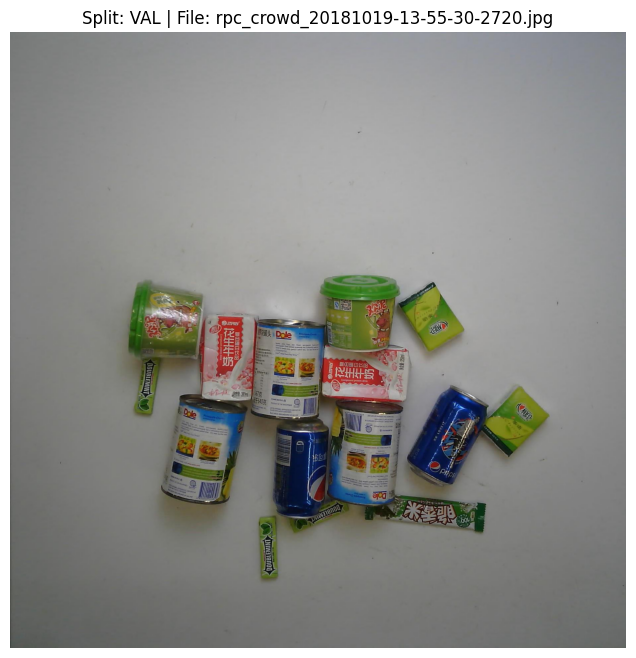

In [23]:
import os
import matplotlib.pyplot as plt
import random
from PIL import Image

# Final Master List (0-16)
master_categories = [
    'dried_fruit', 'stationery', 'canned_food', 'puffed_food', 'gum', 
    'tissue', 'milk', 'drink', 'dessert', 'seasoner', 
    'personal_hygiene', 'alcohol', 'instant_drink', 'dried_food', 
    'instant_noodles', 'chocolate', 'candy'
]

DEST_ROOT = "../data/FINAL_DATASET"

# Choose a random split to verify
split = random.choice(['train', 'val', 'test'])
img_dir = os.path.join(DEST_ROOT, 'images', split)
lbl_dir = os.path.join(DEST_ROOT, 'labels', split)

if os.path.exists(img_dir) and len(os.listdir(img_dir)) > 0:
    # Filter only images
    valid_images = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg', '.webp'))]
    img_name = random.choice(valid_images)
    img_path = os.path.join(img_dir, img_name)
    lbl_path = os.path.join(lbl_dir, img_name.rsplit('.', 1)[0] + ".txt")
    
    # 1. Load and display image FIRST
    img = Image.open(img_path)
    fig, ax = plt.subplots(figsize=(8, 8)) # Use subplots for better control
    ax.imshow(img)
    ax.set_axis_off()
    ax.set_title(f"Split: {split.upper()} | File: {img_name}", fontsize=12)
    
    # 2. Print Integrity Check AFTER plot commands
    print(f"\n--- Data Integrity Check ---")
    print(f"Source Split: {split}")
    print(f"Image Path: {img_path}")
    
    if os.path.exists(lbl_path):
        with open(lbl_path, 'r') as f:
            lines = f.readlines()
            
        print(f"Detected Objects in {img_name}:")
        for line in lines:
            parts = line.split()
            if parts:
                class_id = int(parts[0])
                class_name = master_categories[class_id] if class_id < len(master_categories) else "Unknown"
                print(f"  - [Class ID: {class_id}] -> Name: {class_name}")
    else:
        print(f"⚠️ Warning: Label file missing at {lbl_path}")
    
    # 3. Explicitly call plt.show() and avoid printing the object
    plt.show() 
else:
    print(f"❌ Error: Directory not found or empty: {img_dir}")

### Stage 2: COPY 2000 random images from RPC to saudi data (train/val/test)

In [ ]:
import os
import shutil
import random
from tqdm import tqdm
from collections import defaultdict

# --- Define Paths ---
RPC_BASE = "../data/yolo"
RPC_IMG_SRC = os.path.join(RPC_BASE, "images/train2019")
RPC_LBL_SRC = os.path.join(RPC_BASE, "labels/train2019")


DEST_BASE = "../data/FINAL_DATASET/"

# Target numbers for RPC injection
injection_plan = {
    "train": 2000, # Increased to 2000 as discussed
    "val": 250,
    "test": 250
}

def get_rpc_class_distribution():
    """
    Scans all label files and groups image filenames by their Class ID (0-16).
    """
    print("Scanning RPC labels to group images by class...")
    class_bins = defaultdict(list)
    
    label_files = [f for f in os.listdir(RPC_LBL_SRC) if f.endswith('.txt')]
    
    for lbl_name in tqdm(label_files):
        img_name = lbl_name.rsplit('.', 1)[0] + ".jpg" # Assuming .jpg, adjust if needed
        if not os.path.exists(os.path.join(RPC_IMG_SRC, img_name)):
            continue
            
        with open(os.path.join(RPC_LBL_SRC, lbl_name), 'r') as f:
            lines = f.readlines()
            if not lines: continue
            
            # Get the class ID from the first object in the image
            first_class_id = int(lines[0].split()[0])
            class_bins[first_class_id].append(img_name)
            
    return class_bins

def inject_rpc_stratified():
    # 1. Group images by class first
    class_bins = get_rpc_class_distribution()
    num_classes = 17
    
    # 2. Iterate through each split (train, val, test)
    for split, total_needed in injection_plan.items():
        dest_img_dir = os.makedirs(os.path.join(DEST_BASE, "images", split), exist_ok=True)
        dest_lbl_dir = os.makedirs(os.path.join(DEST_BASE, "labels", split), exist_ok=True)
        
        # Calculate how many images to take from each class (e.g., 2000 / 17 ≈ 117)
        per_class_limit = total_needed // num_classes
        
        print(f"\n🔄 Injecting ~{per_class_limit} images per class into '{split}' split...")
        
        success_count = 0
        for class_id in range(num_classes):
            images_in_class = class_bins[class_id]
            random.shuffle(images_in_class)
            
            # Take a slice for this split and remove them from the bin so they aren't reused
            to_copy = images_in_class[:per_class_limit]
            class_bins[class_id] = images_in_class[per_class_limit:] 
            
            for img_name in to_copy:
                src_img = os.path.join(RPC_IMG_SRC, img_name)
                lbl_name = img_name.rsplit('.', 1)[0] + ".txt"
                src_lbl = os.path.join(RPC_LBL_SRC, lbl_name)
                
                # Copy to destination with rpc_ prefix
                shutil.copy(src_img, os.path.join(DEST_BASE, "images", split, f"rpc_{img_name}"))
                shutil.copy(src_lbl, os.path.join(DEST_BASE, "labels", split, f"rpc_{lbl_name}"))
                success_count += 1
                
        print(f"✅ Injected {success_count} balanced RPC images into {split}.")

# Run the smart injection
inject_rpc_stratified()

Scanning RPC labels to group images by class...


100%|██████████| 53739/53739 [00:04<00:00, 12529.47it/s]



🔄 Injecting ~117 images per class into 'train' split...
✅ Injected 1989 balanced RPC images into train.

🔄 Injecting ~14 images per class into 'val' split...
✅ Injected 238 balanced RPC images into val.

🔄 Injecting ~14 images per class into 'test' split...
✅ Injected 238 balanced RPC images into test.


In [9]:
import os
import shutil
import random
from tqdm import tqdm

# --- 1. Master Mapping Logic ---
def get_new_id(old_id):
    # This logic ONLY applies to RAW RPC IDs (0-199)
    # If the ID is already 0-16, return it as is (Safety Check)
    if old_id < 17:
        return old_id
        
    if 0 <= old_id <= 21:    return 3  # puffed_food
    elif 22 <= old_id <= 30:  return 0  # dried_fruit
    elif 31 <= old_id <= 41:  return 12 # instant_drink
    elif 42 <= old_id <= 51:  return 8  # dessert
    elif 52 <= old_id <= 62:  return 14 # instant_noodles
    elif 63 <= old_id <= 73:  return 2  # canned_food
    elif 74 <= old_id <= 83:  return 7  # drink
    elif 84 <= old_id <= 93:  return 11 # alcohol
    elif 94 <= old_id <= 105: return 6  # milk
    elif 106 <= old_id <= 115: return 9  # seasoner
    elif 116 <= old_id <= 127: return 10 # personal_hygiene
    elif 128 <= old_id <= 138: return 5  # tissue
    elif 139 <= old_id <= 148: return 1  # stationery
    elif 149 <= old_id <= 158: return 16 # candy
    elif 159 <= old_id <= 168: return 4  # gum
    elif 169 <= old_id <= 179: return 15 # chocolate
    elif 180 <= old_id <= 199: return 13 # dried_food
    return 0 # Default

# --- 2. Paths ---
RPC_RAW_IMG_SRC = "../data/yolo/images/test2019" 
RPC_RAW_LBL_SRC = "../data/yolo/labels/test2019" 
DEST_BASE = "../data/FINAL_DATASET"

def fix_data_integrity(split_name, num_samples=250):
    dest_img_dir = os.path.join(DEST_BASE, "images", split_name)
    dest_lbl_dir = os.path.join(DEST_BASE, "labels", split_name)

    # A. PURGE: Delete all previous rpc_crowd files to start clean
    print(f"🧹 Purging corrupted files from {split_name}...")
    for f in os.listdir(dest_img_dir):
        if f.startswith("rpc_crowd_"):
            os.remove(os.path.join(dest_img_dir, f))
            lbl_f = f.rsplit('.', 1)[0] + ".txt"
            if os.path.exists(os.path.join(dest_lbl_dir, lbl_f)):
                os.remove(os.path.join(dest_lbl_dir, lbl_f))

    # B. RESYNC: Get fresh samples
    all_files = [f for f in os.listdir(RPC_RAW_IMG_SRC) if f.lower().endswith(('.jpg', '.png', '.jpeg', '.webp'))]
    sampled = random.sample(all_files, num_samples)

    print(f"🚀 Injecting {num_samples} images into {split_name} with line-by-line remapping...")
    success_count = 0
    for img_name in tqdm(sampled):
        src_img = os.path.join(RPC_RAW_IMG_SRC, img_name)
        src_lbl = os.path.join(RPC_RAW_LBL_SRC, img_name.rsplit('.', 1)[0] + ".txt")

        if os.path.exists(src_lbl):
            new_filename = f"rpc_crowd_{img_name}"
            # 1. Copy Image
            shutil.copy(src_img, os.path.join(dest_img_dir, new_filename))

            # 2. READ Label line by line, APPLY Map per object, and SAVE
            with open(src_lbl, 'r') as f:
                lines = f.readlines()
            
            corrected_lines = []
            for line in lines:
                parts = line.split()
                if parts:
                    raw_id = int(parts[0])
                    # Fix: Each object's ID is remapped independently
                    new_id = get_new_id(raw_id) 
                    parts[0] = str(new_id)
                    corrected_lines.append(" ".join(parts) + "\n")
            
            # Save the corrected label
            lbl_filename = new_filename.rsplit('.', 1)[0] + ".txt"
            with open(os.path.join(dest_lbl_dir, lbl_filename), 'w') as f:
                f.writelines(corrected_lines)
            success_count += 1

    print(f"✅ Split {split_name} is FIXED. {success_count} images processed.")

# Run
fix_data_integrity("val", 250)
fix_data_integrity("test", 250)
print("\n🏁 DONE! Run your Random Check cell again to verify.")

🧹 Purging corrupted files from val...
🚀 Injecting 250 images into val with line-by-line remapping...


100%|██████████| 250/250 [00:00<00:00, 609.44it/s]


✅ Split val is FIXED. 250 images processed.
🧹 Purging corrupted files from test...
🚀 Injecting 250 images into test with line-by-line remapping...


100%|██████████| 250/250 [00:00<00:00, 592.58it/s]

✅ Split test is FIXED. 250 images processed.

🏁 DONE! Run your Random Check cell again to verify.


### Stage 3: Over sample Saudi Data

In [86]:
import os
import shutil

#number of all images before oversampling
total_train_images_before = len(os.listdir(os.path.join(DEST_BASE, "images", "train")))
print(f"📊 Total images in TRAIN before oversampling: {total_train_images_before}")

## Oversampling Configuration oversample only the SAUDI data (not RPC) in the train split to reach a total of 1000 images
## SAUDI data start with "abd_" or "tahir_" prefix, while RPC data start with "rpc_"

oversample_target = 3000  # Desired number of images in the train split after oversampling


def oversample_saudi_data():

    #define paths
    train_img_dir = os.path.join(DEST_BASE, "images", "train")
    train_lbl_dir = os.path.join(DEST_BASE, "labels", "train")
    # Get all Saudi images (those that do NOT start with "rpc_")
    saudi_images = [f for f in os.listdir(train_img_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg','webp')) and not f.startswith("rpc_")]
    current_count = len(saudi_images)
    print(f"📊 Current Saudi images in TRAIN: {current_count}")

    if current_count >= oversample_target:
        print("✅ No oversampling needed. Already at or above target.")
        return

    # Calculate how many more images we need to reach the target
    needed = oversample_target - current_count
    print(f"🔄 Oversampling needed: {needed} additional images.")
    # We will duplicate existing Saudi images to reach the target
    idx = 0
    while current_count < oversample_target:
        img_name = saudi_images[idx % len(saudi_images)]  # Loop through existing images
        src_img_path = os.path.join(train_img_dir, img_name)
        lbl_name = img_name.rsplit('.', 1)[0] + ".txt"
        src_lbl_path = os.path.join(train_lbl_dir, lbl_name)

        # Create new filenames with an oversample prefix and index
        new_img_name = f"oversample_{idx}_{img_name}"
        new_lbl_name = f"oversample_{idx}_{lbl_name}"
        dest_img_path = os.path.join(train_img_dir, new_img_name)
        dest_lbl_path = os.path.join(train_lbl_dir, new_lbl_name)

        # Copy the image and label to create a new sample
        shutil.copy(src_img_path, dest_img_path)
        shutil.copy(src_lbl_path, dest_lbl_path)

        current_count += 1
        idx += 1

    print(f"✅ Oversampling complete. Total Saudi images in TRAIN after oversampling: {current_count}")

# Run the oversampling
oversample_saudi_data()


📊 Total images in TRAIN before oversampling: 2654
📊 Current Saudi images in TRAIN: 665
🔄 Oversampling needed: 2335 additional images.
✅ Oversampling complete. Total Saudi images in TRAIN after oversampling: 3000


In [87]:
# see the number of train and test images that belong to RPC dataset vs Saudi dataset
# saudi images start with "abd_" or "tahir_" or "oversample_", while RPC images start with "rpc_"


DEST_BASE = "../data/FINAL_DATASET/"


#start with training images distribution:

train_img_dir = os.path.join(DEST_BASE, "images", "train")
saudi_count = 0
rpc_count = 0
for img in os.listdir(train_img_dir):
    if img.startswith(('abd_', 'tahir_','oversample_')):
        saudi_count += 1
    elif img.startswith('rpc_'):
        rpc_count += 1
print(f"📊 TRAINING IMAGES DISTRIBUTION:")
print(f"  Saudi Images: {saudi_count}")
print(f"  RPC Images: {rpc_count}")


#testing images distribution:
test_img_dir = os.path.join(DEST_BASE, "images", "test")
saudi_count = 0
rpc_count = 0
for img in os.listdir(test_img_dir):
    if img.startswith(('abd_', 'tahir_')):
        saudi_count += 1
    elif img.startswith('rpc_'):
        rpc_count += 1
print(f"\n📊 TESTING IMAGES DISTRIBUTION:"
      f"  Saudi Images: {saudi_count}"
      f"  RPC Images: {rpc_count}")
      


📊 TRAINING IMAGES DISTRIBUTION:
  Saudi Images: 3000
  RPC Images: 1989

📊 TESTING IMAGES DISTRIBUTION:  Saudi Images: 144  RPC Images: 238


### Stage 4: start Fine-Tuning

In [ ]:
import os
from ultralytics import YOLO

# 1. Model Path: Start from the 5-epoch weights that showed initial success
# Ensure this points to the correct path of the best weights from the short run
WARM_MODEL_PATH = "../runs/Saudi_Final_Run/weights/best.pt"
model = YOLO(WARM_MODEL_PATH)

# 2. Define the final save directory
project_dir = '/home/abd0_linux/Sync/University/الترم الثاني/Computer Vision/CV_Project/Vision-Checkout/runs'

# 3. Final Training (100 Epochs)
results = model.train(
    # --- Paths ---
    data='../data/FINAL_DATASET/data.yaml', 
    project=project_dir,
    name='Saudi_Final_ULTRA',  # Final name for the run (will create a folder with this name)
    
    # --- Basic Hyperparameters ---
    epochs=100,
    imgsz=640,
    batch=16,           # Reduce to 8 if Out of Memory (OOM) occurs
    device=0,
    workers=12,
    optimizer='AdamW',  # Most reliable for excellent results in record time
    lr0=0.0005,         # Slightly reduced learning rate since starting from 'warm' weights
    lrf=0.01,
    warmup_epochs=0,    # No warmup needed since the model is already pre-trained
    freeze=5,           # Reduced freezing to allow more flexibility for learning Saudi data
    patience=25,        # Early stopping if accuracy plateaus
    
    # --- NATIVE EXTREME AUGMENTATIONS (YOLO's built-in power) ---
    mosaic=1.0,         # Maximum mosaic augmentation (merges 4 images)
    mixup=0.5,          # High mixup ratio (prevents over-fitting/memorization)
    scale=0.9,          # Random scaling (0.9 represents significant variation)
    perspective=0.0005, # Angled perspective views
    degrees=20.0,       # Increased random rotation angle
    shear=5.0,          # Shear images at side angles
    translate=0.1,      # Translate products within the frame
    hsv_h=0.02,         # Stronger hue manipulation
    hsv_s=0.8,          # Saturation manipulation
    hsv_v=0.5,          # Brightness manipulation (simulates supermarket lighting)
    fliplr=0.5,         # Horizontal flip
    flipud=0.5,         # Vertical flip (simulates overhead camera angles)
    erasing=0.5,        # Randomly hides parts of products (simulates cashier's hand or occlusion)
    
    # --- Saving Configurations ---
    save_period=10,
    val=True,
    plots=True
)

print(f"🚀 Final training started! The legendary model will be saved at: {project_dir}/Saudi_Final_Grand_Finale/weights/best.pt")

In [ ]:
import os
from ultralytics import YOLO

# 1. PATH CONFIGURATION
# Start from your Saudi-trained weights (20 epochs) to maintain momentum
# Ensure this points to your latest 'best.pt' or 'last.pt'"
project_dir = '/home/abd0_linux/Sync/University/الترم الثاني/Computer Vision/CV_Project/Vision-Checkout/runs'

# Load the model with pre-trained Saudi knowledge
model = YOLO('../runs/Saudi_Final_ULTRA/weights/best.pt')

# 2. THE ATOMIC TRAINING (Extreme Augmentation + Data Rehearsal Support)
results = model.train(
    # --- Data & Workspace ---
    data='../data/FINAL_DATASET/data.yaml', 
    project=project_dir,
    name='Saudi_Final_ULTRA_MAX',  
    
    # --- Core Hyperparameters ---
    epochs=80,                  # Remaining cycles to converge on crowded data
    imgsz=640,                  # High resolution for fine-grained retail detection
    batch=16,                   # Adjust to 8 if you face CUDA Out of Memory (OOM)
    device=0,                   # Primary GPU
    workers=12,                 # Multi-threaded data loading
    optimizer='AdamW',          # Faster convergence for fine-tuning
    lr0=0.001,                  # Increased LR to overcome heavy freezing/augmentation
    lrf=0.01,                   # Final LR fraction for smooth stabilization
    warmup_epochs=3,            # 3 epochs to stabilize gradients after changing data difficulty
    patience=50,                # High patience to allow model to recover from "Crowded Validation" shock
    
    # ---  ARCHITECTURAL STABILITY ---
    freeze=10,                  # Freeze the entire backbone to protect RPC global features (9 classes)
    
    # --- NATIVE ATOMIC AUGMENTATIONS (Extreme mode enabled) ---
    mosaic=1.0,                 # Mandatory for crowded checkout scenes (Max value)
    mixup=0.8,                  # Extreme blending of images to prevent brand logo memorization
    copy_paste=0.5,             # Artificially clones objects into scenes to simulate high overlap
    
    scale=0.9,                  # Extreme scale jitter (0.9 to simulate far/near products)
    perspective=0.001,          # Sharp camera angles mimicking high-shelf views
    degrees=30.0,               # Heavy rotations (30 deg) for products on conveyor belts
    shear=15.0,                 # Distort object corners to simulate lens distortion
    translate=0.2,              # Large translations (0.2) to simulate off-center captures
    
    # --- PHOTOMETRIC TRANSFORMATIONS (Lighting Invariance) ---
    hsv_h=0.05,                 # Drastic hue shifts to handle varied Saudi packaging colors
    hsv_s=0.9,                  # Intense saturation shifts for varying display vibrance
    hsv_v=0.9,                  # Extreme brightness/contrast jitter for harsh LED/Shadow conditions
    
    # --- PHYSICAL REALISM ---
    fliplr=0.5,                 # Horizontal flipping
    flipud=0.5,                 # Vertical flipping for overhead camera perspective invariance
    erasing=0.6,                # Hide 60% of the product! Force model to identify from partial features
    
    # --- LOGGING & ANALYSIS ---
    save_period=5,              # Checkpoint safety every 5 epochs
    val=True,                   # Monitor real performance on Crowded Val set
    plots=True                  # Generate PR and Confusion Matrix graphs
)

print(f"🏁 Saudi Extreme V4 is live! Model cooking at: {project_dir}/Saudi_Final_Extreme_V4")

In [ ]:
# resume TRAINING
from ultralytics import YOLO

model = YOLO('../runs/Saudi_Final_ULTRA_MAX/weights/last.pt')  # Load the last checkpoint to resume training
model.train(
    resume=True               
)

In [2]:
# run the model on new images to see the performance (runs/Saudi_Final_ULTRA_MAX/test_images)

model = YOLO('../runs/Saudi_Final_ULTRA_MAX/weights/best.pt')  # Load the best checkpoint for inference

#only save the images with predictions (not all test images)
results = model.predict(source='../runs/Saudi_Final_ULTRA_MAX/test_images', save=True)  # Run inference on new images and save results


image 1/12 /home/abd0_linux/Sync/University/الترم الثاني/Computer Vision/CV_Project/Vision-Checkout/notebooks/../runs/Saudi_Final_ULTRA_MAX/test_images/1.png: 640x640 1 dessert, 29.0ms
image 2/12 /home/abd0_linux/Sync/University/الترم الثاني/Computer Vision/CV_Project/Vision-Checkout/notebooks/../runs/Saudi_Final_ULTRA_MAX/test_images/2.jpg: 480x640 3 milks, 1 drink, 52.2ms
image 3/12 /home/abd0_linux/Sync/University/الترم الثاني/Computer Vision/CV_Project/Vision-Checkout/notebooks/../runs/Saudi_Final_ULTRA_MAX/test_images/3.jpg: 640x640 2 canned_foods, 1 instant_noodles, 29.6ms
image 4/12 /home/abd0_linux/Sync/University/الترم الثاني/Computer Vision/CV_Project/Vision-Checkout/notebooks/../runs/Saudi_Final_ULTRA_MAX/test_images/4.jpg: 416x640 14 canned_foods, 5 drinks, 4 instant_noodless, 1 chocolate, 2 candys, 161.9ms
image 5/12 /home/abd0_linux/Sync/University/الترم الثاني/Computer Vision/CV_Project/Vision-Checkout/notebooks/../runs/Saudi_Final_ULTRA_MAX/test_images/5.jpg: 384x640 1

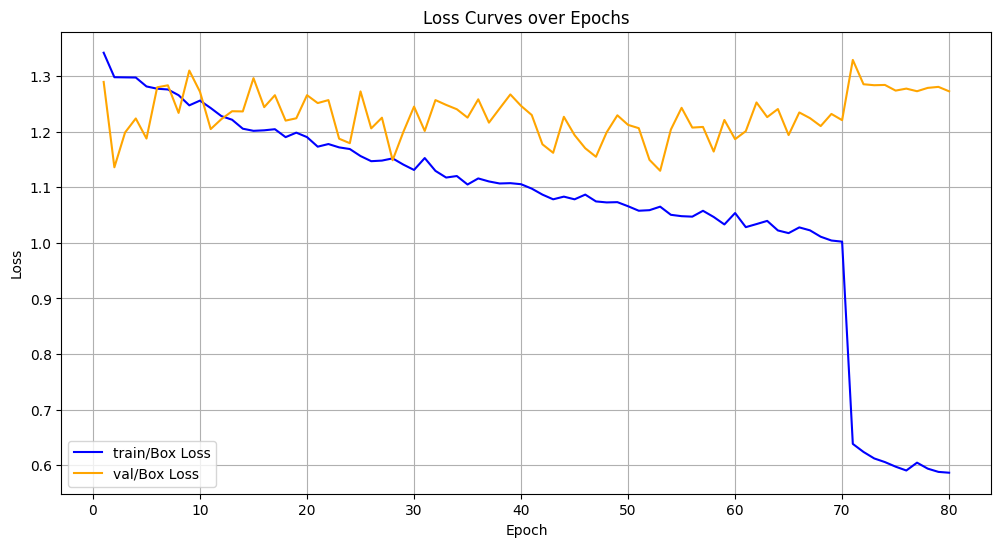

In [ ]:
# plot the model performance metrics (PR curve, confusion matrix, etc.) from the training results
# use the results.csv file generated in the run directory to plot the metrics
import pandas as pd
import matplotlib.pyplot as plt 
#import seaborn as sns

%matplotlib inline

df = pd.read_csv('../runs/Saudi_Final_ULTRA_MAX/results.csv')

df.head()

# plot box_loss, cls_loss, dfl_loss over epochs (train and val)
plt.figure(figsize=(12,6))

#create subplot for box_loss , cls_loss. 
plt.subplot(1, 2, 1)
plt.plot(df['epoch'], df['train/box_loss'], label='train/Box Loss', color='blue')
plt.plot(df['epoch'], df['val/box_loss'], label='val/Box Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Box Loss')
plt.title('Box Loss Curves over Epochs')
plt.legend()
plt.grid()

#cls_loss subplot
plt.subplot(1,3,2)
plt.plot(df['epoch'], df['train/cls_loss'], label='train/Cls Loss', color='blue')
plt.plot(df['epoch'], df['val/cls_loss'], label='val/Cls Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Cls Loss')
plt.title('Classification Loss Curves over Epochs')
plt.legend()
plt.grid()


